In [8]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
# Seed zapewnia identyczne dane u każdego studenta
np.random.seed(42)
n = 200
dzialy = np.random.choice(['IT', 'Sprzedaz', 'HR', 'Marketing', 'Finanse'], n,
p=[0.30, 0.25, 0.15, 0.20, 0.10])
staz = np.random.gamma(shape=3, scale=2, size=n).clip(0.5, 20).round(1)
baza = {'IT': 9000, 'Sprzedaz': 7000, 'HR': 6500, 'Marketing': 7500, 'Finanse': 
8500}
wynagrodzenie = np.array([
baza[d] + staz[i] * 300 + np.random.normal(0, 1200)
for i, d in enumerate(dzialy)
]).clip(4000, 25000).round(-2)
# 5 celowo wstawionych outlierów (błędy danych / kontrakty specjalne)
wynagrodzenie[np.random.choice(n, 5, replace=False)] = np.random.choice(
[2000, 2500, 35000, 40000, 38000], 5, replace=False)
df = pd.DataFrame({
'dzial': dzialy,
'staz_lat': staz,
'wynagrodzenie': wynagrodzenie,
'wiek': (25 + staz + np.random.normal(0, 3, n)).clip(22, 
65).round().astype(int),
'ocena_roczna': np.random.choice([1, 2, 3, 4, 5], n, p=[0.05, 0.10, 0.40, 
0.35, 0.10])
})
print(f"Dataset HR: {df.shape[0]} pracowników, {df.shape[1]} kolumn")
print(df.head())
print("\nTypy kolumn:")
print(df.dtypes)

Dataset HR: 200 pracowników, 5 kolumn
       dzial  staz_lat  wynagrodzenie  wiek  ocena_roczna
0   Sprzedaz       3.4         9100.0    27             5
1    Finanse       6.1        12600.0    35             3
2  Marketing       6.3         7700.0    38             3
3         HR       3.3         8200.0    27             4
4         IT      14.0        12400.0    38             4

Typy kolumn:
dzial                str
staz_lat         float64
wynagrodzenie    float64
wiek               int64
ocena_roczna       int64
dtype: object


### Ćwiczenie 1
Statystyki opisowe na danych biznesowych

In [6]:
placa = df['wynagrodzenie']

srednia  = placa.mean()
mediana  = placa.median()
dominanta = placa.mode().iloc[0]

print("=== MIARY TENDENCJI CENTRALNEJ ===")
print(f"Średnia: {srednia:>10,.0f} PLN")
print(f"Mediana: {mediana:>10,.0f} PLN")
print(f"Dominanta: {dominanta:>10,.0f} PLN")

=== MIARY TENDENCJI CENTRALNEJ ===
Średnia:      9,940 PLN
Mediana:      9,450 PLN
Dominanta:      9,500 PLN


Mediana jest mniejsza od średniej, świadczy to o prawostronnej skośności rozkładu.


Mediana jest niższa, ponieważ średnia jest zawyżana przez skrajne, bardzo wysokie wartości wynagrodzeń osób na kontraktach specjalnych (3 osoby które otrzymały pensję w wysokości 35000 PLN, 38000 PLN i 40000 PLN).

In [9]:
odch_std = placa.std()
q1 = placa.quantile(0.25)
q3 = placa.quantile(0.75)
iqr = q3 - q1
rozstep = placa.max() - placa.min()
print("=== MIARY ROZPROSZENIA ===")
print(f"Odchylenie std: {odch_std:>10,.0f} PLN")
print(f"Q1 (P25): {q1:>10,.0f} PLN")      
print(f"Q3 (P75): {q3:>10,.0f} PLN")      
print(f"IQR: {iqr:>10,.0f} PLN")           
print(f"Rozstęp: {rozstep:>10,.0f} PLN")       


=== MIARY ROZPROSZENIA ===
Odchylenie std:      3,980 PLN
Q1 (P25):      8,200 PLN
Q3 (P75):     10,700 PLN
IQR:      2,500 PLN
Rozstęp:     38,000 PLN


Rozstęp to różnica między najwyższą a najniższą pensją w firmie, jest tak duży przez wspomniane już wcześniej skrajnie wysokie wartości pochodzące z błędów danych lub kontaktów specjalnych.

In [10]:
dzialy_stats = df.groupby('dzial', observed=True)['wynagrodzenie'].agg([
'mean', 'median', 'std'
]).round(0).sort_values('median', ascending=False)
dzialy_stats.columns = ['Średnia', 'Mediana', 'Std']
print("=== WYNAGRODZENIA PER DZIAŁ ===")
print(dzialy_stats)

=== WYNAGRODZENIA PER DZIAŁ ===
           Średnia  Mediana     Std
dzial                              
IT         11108.0  10600.0  4145.0
Finanse    10621.0  10400.0  1741.0
Marketing   9476.0   9100.0  4386.0
HR          8354.0   8400.0  1622.0
Sprzedaz    9282.0   8400.0  4428.0


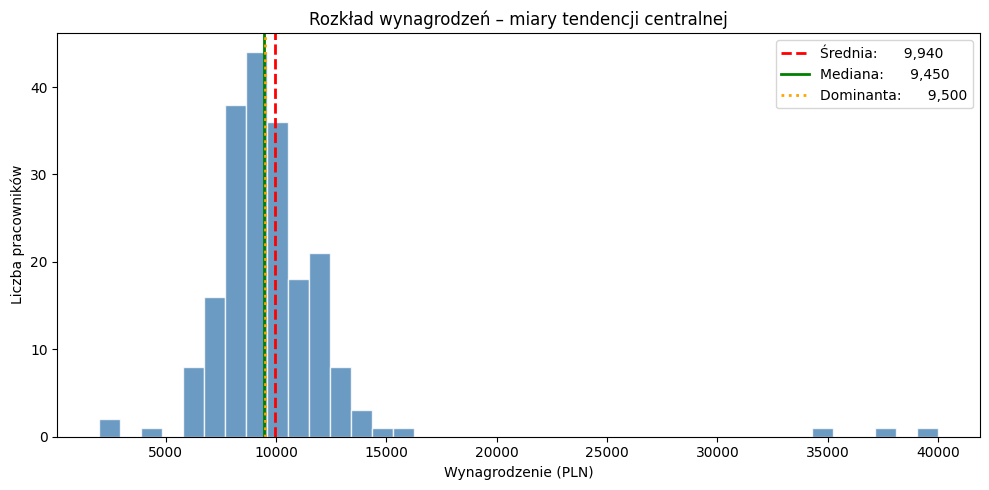

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

# Uzupełnij ___ wartościami:
ax.hist(placa, bins=40, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(srednia, color='red', linestyle='--', lw=2, label=f'Średnia: {srednia:>10,.0f}')
ax.axvline(mediana, color='green', linestyle='-', lw=2, label=f'Mediana: {mediana:>10,.0f}')
ax.axvline(dominanta, color='orange', linestyle=':', lw=2, label=f'Dominanta: {dominanta:>10,.0f}')
# Uwaga: dominanta i mediana mogą się prawie pokryć – to też informacja

ax.set_title('Rozkład wynagrodzeń – miary tendencji centralnej')
ax.set_xlabel('Wynagrodzenie (PLN)')
ax.set_ylabel('Liczba pracowników')
ax.legend()
plt.tight_layout()
plt.show()
plt.close()

### Ćwiczenie 2 
Analiza korelacji

In [12]:
r, p_value = stats.pearsonr(df['staz_lat'], df['wynagrodzenie'])
print(f"Korelacja Pearsona (staż–wynagrodzenie):")
print(f"  r = {r:.4f}")
print(f"  p = {p_value:.4f}")
print(f"  Interpretacja: {'istotna' if p_value < 0.05 else 'nieistotna'} statystycznie")

Korelacja Pearsona (staż–wynagrodzenie):
  r = 0.3198
  p = 0.0000
  Interpretacja: istotna statystycznie


In [14]:
rho, p_rho = stats.spearmanr(df['staz_lat'], df['wynagrodzenie'])
print(f"Korelacja Spearmana (staż–wynagrodzenie):")
print(f"  rho = {rho:.4f}")
print(f"  p   = {p_rho:.4f}")
print(f"\nPorównanie: Pearson r = {r:.3f} vs Spearman rho = {rho:.3f}")
print(f"Różnica: {abs(rho - r):.3f} — {'duże' if abs(rho-r) > 0.1 else 'małe'} rozbieżności")

Korelacja Spearmana (staż–wynagrodzenie):
  rho = 0.5219
  p   = 0.0000

Porównanie: Pearson r = 0.320 vs Spearman rho = 0.522
Różnica: 0.202 — duże rozbieżności


Korelacja Spearmana daje wyższy wynik niż korelacja Pearsona, ponieważ jest odporna na wartości skrajne.

Macierz korelacji Pearsona:
               staz_lat  wynagrodzenie   wiek  ocena_roczna
staz_lat          1.000          0.320  0.756        -0.057
wynagrodzenie     0.320          1.000  0.219        -0.054
wiek              0.756          0.219  1.000        -0.081
ocena_roczna     -0.057         -0.054 -0.081         1.000


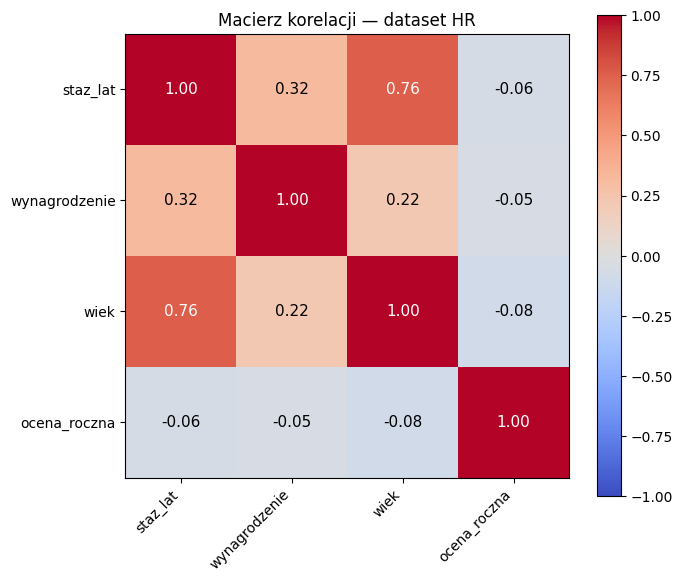

In [15]:
corr = df[['staz_lat', 'wynagrodzenie', 'wiek', 'ocena_roczna']].corr()
print("Macierz korelacji Pearsona:")
print(corr.round(3))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)

for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}',
        ha='center', va='center', fontsize=11,
        color='black' if abs(corr.values[i,j]) < 0.7 else 'white')
        
ax.set_title('Macierz korelacji — dataset HR')
plt.tight_layout()
plt.show()
plt.close()

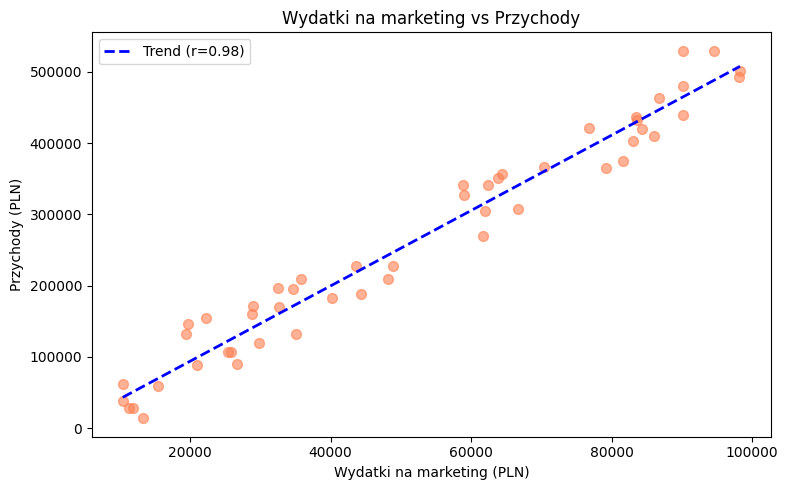

Marketing spend vs Revenue: r = 0.9806, p = 1.22e-35


In [16]:
np.random.seed(100)
n_mkt = 50
marketing_spend = np.random.uniform(10000, 100000, n_mkt)
revenue = marketing_spend * 5.2 + np.random.normal(0, 30000, n_mkt)
revenue = revenue.clip(0)

r_mkt, p_mkt = stats.pearsonr(marketing_spend, revenue)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(marketing_spend, revenue, alpha=0.6, color='coral', s=50)

z = np.polyfit(marketing_spend, revenue, 1)
p_fit = np.poly1d(z)
x_line = np.linspace(marketing_spend.min(), marketing_spend.max(), 100)
ax.plot(x_line, p_fit(x_line), 'b--', lw=2, label=f'Trend (r={r_mkt:.2f})')
ax.set_title('Wydatki na marketing vs Przychody')
ax.set_xlabel('Wydatki na marketing (PLN)')
ax.set_ylabel('Przychody (PLN)')
ax.legend()
plt.tight_layout()
plt.show()
plt.close()
print(f"Marketing spend vs Revenue: r = {r_mkt:.4f}, p = {p_mkt:.2e}")

### Ćwieczenie 3
Pełna analiza statystyczna datasetu HR

In [22]:
dane = stats.describe(df['wynagrodzenie'])

nobs = dane.nobs
min_val, max_val = dane.minmax
mean = dane.mean
variance = dane.variance
skewness = dane.skewness
kurtosis = dane.kurtosis

print("=== PEŁNA ANALIZA STATYSTYCZNA ROZKŁADU WYNAGRODZEŃ ===")
print(f"Liczba obserwacji (nobs): {nobs}")
print(f"Minimum: {min_val:,.0f} PLN")
print(f"Maximum: {max_val:,.0f} PLN")
print(f"Średnia: {mean:,.0f} PLN")
print(f"Wariancja: {variance:,.0f}")
print(f"Skośność: {skewness:.4f}")
print(f"Kurtoza: {kurtosis:.4f}")
print("-" * 55)

if skewness > 1.0:
    interpretacja_skosnosci = "silnie prawoskośny. Zdecydowana większość pracowników zarabia poniżej średniej, a ogólny wynik jest mocno zawyżany przez nieliczne, bardzo wysokie pensje."
elif skewness > 0.1:
    interpretacja_skosnosci = "lekko prawoskośny."
elif skewness < -1.0:
    interpretacja_skosnosci = "silnie lewoskośny. Większość pracowników zarabia bardzo dobrze, a pojedyncze osoby zarabiają drastycznie mało."
else:
    interpretacja_skosnosci = "bliski symetrycznemu."

print(f"Rozkład jest {interpretacja_skosnosci}")

if kurtosis > 0:
    interpretacja_kurtozy = f"Rozkład jest spiczasty z grubymi ogonami (kurtoza > 0). W firmie występuje nienaturalnie dużo ekstremalnych wartości (anomalii płacowych, takich jak kontrakty specjalne lub błędy w danych)"
else:
    interpretacja_kurtozy = "Rozkład jest spłaszczony (kurtoza < 0). Wynagrodzenia są bardziej równomiernie rozproszone wokół średniej."

print(interpretacja_kurtozy)


=== PEŁNA ANALIZA STATYSTYCZNA ROZKŁADU WYNAGRODZEŃ ===
Liczba obserwacji (nobs): 200
Minimum: 2,000 PLN
Maximum: 40,000 PLN
Średnia: 9,940 PLN
Wariancja: 15,838,191
Skośność: 5.1024
Kurtoza: 34.1594
-------------------------------------------------------
Rozkład jest silnie prawoskośny. Zdecydowana większość pracowników zarabia poniżej średniej, a ogólny wynik jest mocno zawyżany przez nieliczne, bardzo wysokie pensje.
Rozkład jest spiczasty z grubymi ogonami (kurtoza > 0). W firmie występuje nienaturalnie dużo ekstremalnych wartości (anomalii płacowych, takich jak kontrakty specjalne lub błędy w danych)


In [23]:
progi = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
percentyle = df['wynagrodzenie'].quantile(progi)

print("=== ANALIZA PERCENTYLOWA WYNAGRODZEŃ ===")
for p, wartosc in percentyle.items():
    print(f"P{int(p*100)}: {wartosc:>10,.0f} PLN")

=== ANALIZA PERCENTYLOWA WYNAGRODZEŃ ===
P10:      7,190 PLN
P25:      8,200 PLN
P50:      9,450 PLN
P75:     10,700 PLN
P90:     12,310 PLN
P95:     13,105 PLN
P99:     35,030 PLN


In [24]:
procent_powyzej_12k = (df['wynagrodzenie'] > 12000).mean() * 100
print(f"Powyżej 12 000 PLN zarabia: {procent_powyzej_12k:.1f}% pracowników")

Powyżej 12 000 PLN zarabia: 13.0% pracowników


Z analizy wynika że próg P75 wynosi dokładnie 10700 PLN. Powyżej 12000 PLN zarabia 13% pracowników.

In [25]:
tabela_dzialy = (
    df.groupby('dzial', observed=True)['wynagrodzenie']
    .agg(
        Średnia='mean',
        Mediana='median',
        Std='std',
        Min='min',
        Max='max',
        IQR=lambda x: x.quantile(0.75) - x.quantile(0.25)
    )
    .sort_values(by='Mediana', ascending=False)
)

tabela_dzialy.round(0)

,Średnia,Mediana,Std,Min,Max,IQR
dzial,,,,,,
IT,11108.0,10600.0,4145.0,2500.0,40000.0,2750.0
Finanse,10621.0,10400.0,1741.0,8300.0,16200.0,2000.0
Marketing,9476.0,9100.0,4386.0,2000.0,35000.0,1500.0
HR,8354.0,8400.0,1622.0,4500.0,10800.0,2425.0
Sprzedaz,9282.0,8400.0,4428.0,5900.0,38000.0,2075.0


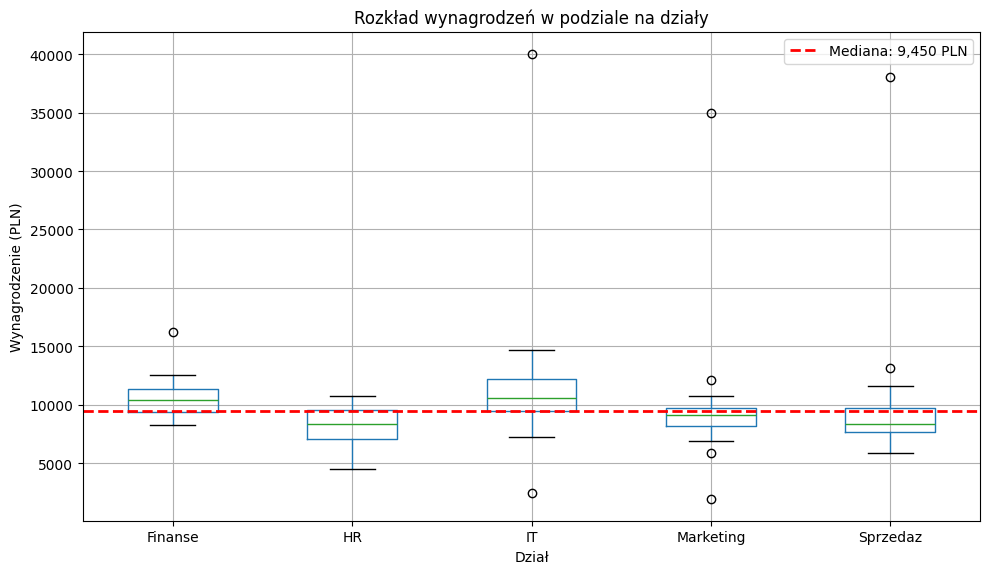

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

df.boxplot(column='wynagrodzenie', by='dzial', ax=ax)

mediana = df['wynagrodzenie'].median()
ax.axhline(mediana, color='red', linestyle='--', lw=2, label=f'Mediana: {mediana:,.0f} PLN')

ax.set_title('Rozkład wynagrodzeń w podziale na działy')
ax.set_xlabel('Dział')
ax.set_ylabel('Wynagrodzenie (PLN)')
ax.legend()

plt.suptitle("") 
plt.tight_layout()
plt.show()

In [30]:
for d in ['IT', 'HR']:
    podzb = df[df['dzial'] == d]['wynagrodzenie']
    opis = stats.describe(podzb)
    print(f"\n{d} (n={opis.nobs}):")
    print(f"  Skośność: {opis.skewness:.3f}")
    print(f"  Kurtoza:  {opis.kurtosis:.3f}")


IT (n=66):
  Skośność: 5.067
  Kurtoza:  34.256

HR (n=24):
  Skośność: -0.460
  Kurtoza:  -0.404


Dział IT ma bardzo wysoką skośność i kurtozę, ponieważ ma najwyższą bazę płac a zarobki szybko rosną wraz ze stażem. Dodatkowo to tam znajdują się płace za kontrakty specjalne. 
Dział HR ma skośność i kurtozę bliską zeru przez niższą bazę płac i brak ekstremalnie wysokich anomalii - wszyscy zarabiają kwoty zbliżone do siebie.

### Ćwiczenie 4
Wykrywanie outlierów

In [31]:
q1 = df['wynagrodzenie'].quantile(0.25)
q3 = df['wynagrodzenie'].quantile(0.75)
iqr = q3 - q1
dolna = q1 - 1.5 * iqr
gorna = q3 + 1.5 * iqr
print(f"IQR granice: [{dolna:,.0f} PLN, {gorna:,.0f} PLN]")

maska_iqr = (df['wynagrodzenie'] < dolna) | (df['wynagrodzenie'] > gorna)
outliery = df[maska_iqr]
print(f"Liczba outlierów: {maska_iqr.sum()} z {len(df)}")
print("\nSzczegóły outlierów:")
print(outliery[['dzial', 'staz_lat', 'wynagrodzenie']].to_string())

IQR granice: [4,450 PLN, 14,450 PLN]
Liczba outlierów: 7 z 200

Szczegóły outlierów:
         dzial  staz_lat  wynagrodzenie
51   Marketing       3.1         2000.0
61          IT      10.6        14700.0
79          IT       6.3        40000.0
83          IT       8.8         2500.0
138   Sprzedaz      13.8        38000.0
154    Finanse      15.3        16200.0
183  Marketing       3.7        35000.0


In [32]:
z_scores = np.abs(stats.zscore(df['wynagrodzenie']))
maska_z = z_scores > 3.0

outliery_z = df[maska_z]
print(f"Outlierzy z-score (|z| > 3.0): {maska_z.sum()} obserwacji")
print(outliery_z[['dzial', 'staz_lat', 'wynagrodzenie']].to_string())

Outlierzy z-score (|z| > 3.0): 3 obserwacji
         dzial  staz_lat  wynagrodzenie
79          IT       6.3        40000.0
138   Sprzedaz      13.8        38000.0
183  Marketing       3.7        35000.0


In [33]:
bez_outlierow = df[~maska_iqr]['wynagrodzenie']
z_outlierami  = df['wynagrodzenie']
print(f"{'Miara':<20} {'Z outlierami':>15} {'Bez outlierów':>15} {'Zmiana':>10}")
print("-" * 62)

for nazwa, f_z, f_bez in [
    ('Średnia', z_outlierami.mean(), bez_outlierow.mean()),
    ('Mediana', z_outlierami.median(), bez_outlierow.median()),
    ('Std',    z_outlierami.std(), bez_outlierow.std()),
]:
    zmiana = f_z - f_bez
    print(f"{nazwa:<20} {f_z:>15,.0f} {f_bez:>15,.0f} {zmiana:>+10,.0f}")

Miara                   Z outlierami   Bez outlierów     Zmiana
--------------------------------------------------------------
Średnia                        9,940           9,532       +408
Mediana                        9,450           9,400        +50
Std                            3,980           1,798     +2,182


W tym przypadku lepiej sprawdza się metoda IQR, ponieważ dzięki użyciu kwartyli do wyznaczenia granic jest odporna na anomalie i daje bardziej realne wyniki.